<a href="https://colab.research.google.com/github/wataruhisano/MLB_salary_prediction/blob/main/mlb_salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pybaseball mlb-statsapi duckdb

In [ ]:
import os
import pandas as pd
import duckdb
import re
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import shutil
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)


seed_everything(SEED)

In [ ]:
# 1. マウント

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# --- 1. 設定  ---
DRIVE_PATH = '/content/drive/My Drive/個人開発/MLB_DATA_PREDICT/data/'
LOCAL_DB_PATH = '/content/mlb_analytics.duckdb'
SALARY_CSV = os.path.join(DRIVE_PATH, 'mlb_salary_data.csv')


In [ ]:
# 既存のDBがあればDriveからローカルにコピー（継続開発用）

if os.path.exists(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb')):

    shutil.copy(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'), LOCAL_DB_PATH)

    print("Existing database copied from Drive to local.")

In [ ]:
# DuckDB接続
con = duckdb.connect(LOCAL_DB_PATH)

In [ ]:
# --- 2. データクリーニング関数の定義 ---
def clean_salary(x):
    """$5,850,000 のような文字列を数値に変換"""
    if isinstance(x, str):
        return float(re.sub(r'[$,]', '', x))
    return x

def clean_name(x):
    """Matt Wallner* のような名前末尾の記号を除去"""
    if isinstance(x, str):
        return re.sub(r'[*#]', '', x).strip()
    return x

In [ ]:
# --- 3. Salaryデータの読み込みとDuckDB格納 ---
if os.path.exists(SALARY_CSV):
    salary_raw = pd.read_csv(SALARY_CSV, encoding='latin1')
    # クリーニング
    salary_raw['Salary_Numeric'] = salary_raw['Salary'].apply(clean_salary)
    salary_raw['Name_Clean'] = salary_raw['Name'].apply(clean_name)

    # DuckDBへテーブル作成
    con.execute("CREATE OR REPLACE TABLE t_salary AS SELECT * FROM salary_raw")
    print("Salary data loaded and stored in DuckDB.")
else:
    print("エラー: Salary CSVが見つかりません。")

Salary data loaded and stored in DuckDB.


In [ ]:
# --- 4. 年度別Baseball Referenceデータの読み込み (2022-2024) ---
# ファイル名が '2022_stats.csv' 等であると仮定（適宜修正してください）
years = [2017,2018,2019,2021,2022, 2023, 2024]
all_stats_list = []

for year in years:
    # ファイルパス構築（例: DRIVE_PATH/2022_stats.csv）
    stats_file = os.path.join(DRIVE_PATH, f'{year}_stats.csv')

    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file)
        df['Year'] = year
        # 提示された形式に基づき、Nameのクレンジング
        if 'Name' in df.columns:
            df['Name_Clean'] = df['Name'].apply(clean_name)
        else:

            df['Name_Clean'] = df.iloc[:, 1].apply(clean_name)

        all_stats_list.append(df)
        print(f"Loaded stats for {year}")

if all_stats_list:
    full_stats_df = pd.concat(all_stats_list)
    con.execute("CREATE OR REPLACE TABLE t_stats AS SELECT * FROM full_stats_df")
else:
    print("エラー: 年度別の統計データが見つかりません。")

Loaded stats for 2017
Loaded stats for 2018
Loaded stats for 2019
Loaded stats for 2021
Loaded stats for 2022
Loaded stats for 2023
Loaded stats for 2024


In [ ]:
# --- 4.5 FanGraphsデータの読み込み (2022-2024) ---
# ファイル名が 'fg_stats_2022.csv' 等であると仮定
fg_years =  [2017,2018,2019,2021,2022, 2023, 2024]
all_fg_list = []

for year in fg_years:
    fg_file = os.path.join(DRIVE_PATH, f'fg_stats_{year}.csv') # 実際のファイル名に変更してください

    if os.path.exists(fg_file):
        df_fg = pd.read_csv(fg_file)
        df_fg['Year'] = year

        # 名前列の特定とクレンジング
        # FGは1列目に "1Aaron Judge" のように番号がくっついている場合があるため注意
        if 'Name' in df_fg.columns:
            df_fg['Name_Clean'] = df_fg['Name'].apply(clean_name)
        else:
            # 列名がない場合、1列目を加工
            df_fg['Name_Clean'] = df_fg.iloc[:, 0].str.replace(r'^\d+', '', regex=True).apply(clean_name)

        all_fg_list.append(df_fg)
        print(f"Loaded FanGraphs {year}")

if all_fg_list:
    full_fg_df = pd.concat(all_fg_list)
    # DuckDBへ格納 (既にある指標と重複を避けるためテーブル名を分ける)
    con.execute("CREATE OR REPLACE TABLE t_fg_stats AS SELECT * FROM full_fg_df")
else:
    print("エラー: FanGraphsデータが見つかりません。")

Loaded FanGraphs 2017
Loaded FanGraphs 2018
Loaded FanGraphs 2019
Loaded FanGraphs 2021
Loaded FanGraphs 2022
Loaded FanGraphs 2023
Loaded FanGraphs 2024


In [ ]:
# それぞれのテーブルから名前を5件ずつ表示して形式を比較
print("--- t_stats の名前サンプル ---")
print(con.execute("SELECT Name_Clean, Year FROM t_stats LIMIT 5").df())

print("\n--- t_salary の名前サンプル ---")
print(con.execute("SELECT Name_Clean, Year FROM t_salary LIMIT 5").df())

--- t_stats の名前サンプル ---
          Name_Clean  Year
0        Jose Altuve  2017
1        Aaron Judge  2017
2  Giancarlo Stanton  2017
3  Andrelton Simmons  2017
4         Joey Votto  2017

--- t_salary の名前サンプル ---
      Name_Clean  Year
0  Kelly Johnson  2011
1   Joe Saunders  2011
2    Chris Young  2011
3   Stephen Drew  2011
4   Justin Upton  2011


In [ ]:
# 結合して重複が出ている状態のDFを作成
df_model = con.execute("""
SELECT
    s.Name_Clean as s_name,
    f.Name_Clean as f_name,
    s.Year,
    s.Team
FROM t_stats s
JOIN t_fg_stats f
  ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(f.Name_Clean AS VARCHAR)))
 AND s.Year = f.Year
""").df()

# 重複している「名前と年のペア」を特定
dups = df_model[df_model.duplicated(subset=['s_name', 'Year'], keep=False)]

# 重複している人の「実際の表記」を比較する
# ここで大文字小文字の違いや、Tm（チーム）の違いが見えるはずです
print(dups.sort_values(['s_name', 'Year']).head(20))

                s_name             f_name  Year Team
561        Adam Duvall        Adam Duvall  2021  2TM
562        Adam Duvall        Adam Duvall  2021  MIA
563        Adam Duvall        Adam Duvall  2021  ATL
520       Adam Frazier       Adam Frazier  2021  2TM
521       Adam Frazier       Adam Frazier  2021  PIT
522       Adam Frazier       Adam Frazier  2021  SDP
710  Andrew Benintendi  Andrew Benintendi  2022  2TM
711  Andrew Benintendi  Andrew Benintendi  2022  KCR
712  Andrew Benintendi  Andrew Benintendi  2022  NYY
244   Andrew McCutchen   Andrew McCutchen  2018  2TM
245   Andrew McCutchen   Andrew McCutchen  2018  SFG
246   Andrew McCutchen   Andrew McCutchen  2018  NYY
587      Anthony Rizzo      Anthony Rizzo  2021  2TM
588      Anthony Rizzo      Anthony Rizzo  2021  CHC
589      Anthony Rizzo      Anthony Rizzo  2021  NYY
277   Asdrúbal Cabrera   Asdrúbal Cabrera  2018  2TM
278   Asdrúbal Cabrera   Asdrúbal Cabrera  2018  NYM
279   Asdrúbal Cabrera   Asdrúbal Cabrera  201

In [ ]:
# --- 5.2 メインのデータ結合 (実績スコアを追加 + 重複の強制排除) ---
query = """
WITH merged_data AS (
    SELECT
        s.*,
        s.Age * s.Age as Age_Squared,
        ah.mvp_5yr,
        ah.ss_5yr,
        ah.gg_5yr,
        ah.as_5yr,
        (COALESCE(ah.mvp_5yr, 0) * 10 + COALESCE(ah.ss_5yr, 0) * 3 +
         COALESCE(ah.gg_5yr, 0) * 2 + COALESCE(ah.as_5yr, 0) * 1) as career_award_score,

        f.wOBA, f.xwOBA, f."wRC+", f.BsR, f.Off, f.Def, f.ISO, f.BABIP,
        f.AVG AS f_AVG, f.OBP AS f_OBP, f.SLG AS f_SLG, f."BB%", f."K%",
        f.WAR AS fWAR, f.HR AS f_HR,
        y.Salary_Numeric AS target_salary
    FROM t_stats s
    JOIN t_fg_stats f
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(f.Name_Clean AS VARCHAR)))
     AND s.Year = f.Year
    JOIN t_salary y
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(y.Name_Clean AS VARCHAR)))
     AND s.Year = y.Year
    LEFT JOIN t_career_awards ah
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(ah.Name_Clean AS VARCHAR)))
     AND s.Year = ah.Year
    WHERE y.Salary_Numeric > 0
)
SELECT * EXCLUDE(rn) FROM (
    SELECT *,
           -- 同じ名前・年度の中で、PA(打席数)が多い順に番号を振る
           ROW_NUMBER() OVER(PARTITION BY Name_Clean, Year ORDER BY PA DESC) as rn
    FROM merged_data
)
WHERE rn = 1  -- 重複があっても必ず1行だけを抽出
ORDER BY Year, Name_Clean
"""

df_model = con.execute(query).df()

# --- 以降の処理 ---

# Bref側のWARを bWAR にリネームして区別
if 'WAR' in df_model.columns:
    df_model = df_model.rename(columns={'WAR': 'WAR(bref)'})

# FanGraphs側のWARを fWAR にリネームして区別
if 'fWAR' in df_model.columns:
    df_model = df_model.rename(columns={'fWAR': 'WAR(fg)'})

# 重複列の削除と不要な列のドロップ
df_model = df_model.loc[:, ~df_model.columns.duplicated()]
cols_to_drop = [c for c in ['Player', 'Rk'] if c in df_model.columns]
df_model.drop(cols_to_drop, axis=1, inplace=True)

# 欠損値（過去実績がない若手など）を0埋め
award_cols = ['mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score']
df_model[award_cols] = df_model[award_cols].fillna(0)

# 最終確認
print(f"最終的なデータ件数: {len(df_model)}")

最終的なデータ件数: 854


In [ ]:
# 名前と年でグルーピングして、2行以上あるものを探す
dups = df_model.groupby(['Name_Clean', 'Year']).size()
print(dups[dups > 1])

Series([], dtype: int64)


In [ ]:
df_model.shape

(854, 46)

In [ ]:
display(df_model[:].head())

,Age,Team,Lg,PA,Rbat,Rbaser,Rdp,Rfield,Rpos,RAA,...,ISO,BABIP,f_AVG,f_OBP,f_SLG,BB%,K%,WAR(fg),f_HR,target_salary
0,25,NYY,AL,678,58,-1,-1,9,-6,58,...,0.343173,0.356643,0.284133,0.421829,0.627306,0.187316,0.306785,8.694987,52,544500.0
1,28,CIN,NL,647,-1,-3,0,12,-6,2,...,0.231687,0.289673,0.248722,0.301391,0.480409,0.060278,0.262751,2.742537,31,577500.0
2,31,BAL,AL,635,12,2,-2,-14,4,2,...,0.180905,0.312364,0.284757,0.321767,0.465662,0.042520,0.177953,1.437265,26,16000000.0
3,37,LAA,AL,636,-21,0,-5,-1,-14,-41,...,0.145025,0.249480,0.241147,0.286164,0.386172,0.058176,0.146226,-1.808995,23,26000000.0
4,30,KCR,AL,629,-28,0,2,-10,8,-28,...,0.106845,0.290909,0.250417,0.271704,0.357262,0.023847,0.162162,0.474309,6,6500000.0


In [ ]:
# データの形状と型の構成を確認
print(f"データ件数: {len(df_model)} 行")
print(f"カラム数: {len(df_model.columns)} 列")

# 数値型の列とオブジェクト型の列を分ける
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n数値指標 ({len(num_cols)}個): {num_cols}")
print(f"カテゴリ指標 ({len(obj_cols)}個): {obj_cols}")

# 欠損値が多い順に表示（上位10項目）
print("\n--- 欠損値が多い指標 TOP 10 ---")
print(df_model.isnull().sum().sort_values(ascending=False).head(10))

データ件数: 854 行
カラム数: 46 列

数値指標 (40個): ['Age', 'PA', 'Rbat', 'Rbaser', 'Rdp', 'Rfield', 'Rpos', 'RAA', 'WAA', 'Rrep', 'RAR', 'WAR(bref)', 'waaWL%', '162WL%', 'oWAR', 'dWAR', 'oRAR', 'Year', 'Age_Squared', 'mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score', 'wOBA', 'xwOBA', 'wRC+', 'BsR', 'Off', 'Def', 'ISO', 'BABIP', 'f_AVG', 'f_OBP', 'f_SLG', 'BB%', 'K%', 'WAR(fg)', 'f_HR', 'target_salary']
カテゴリ指標 (6個): ['Team', 'Lg', 'Pos', 'Awards', 'Player-additional', 'Name_Clean']

--- 欠損値が多い指標 TOP 10 ---
Awards    474
Age         0
Lg          0
PA          0
Rbat        0
Team        0
Rdp         0
Rfield      0
Rpos        0
RAA         0
dtype: int64


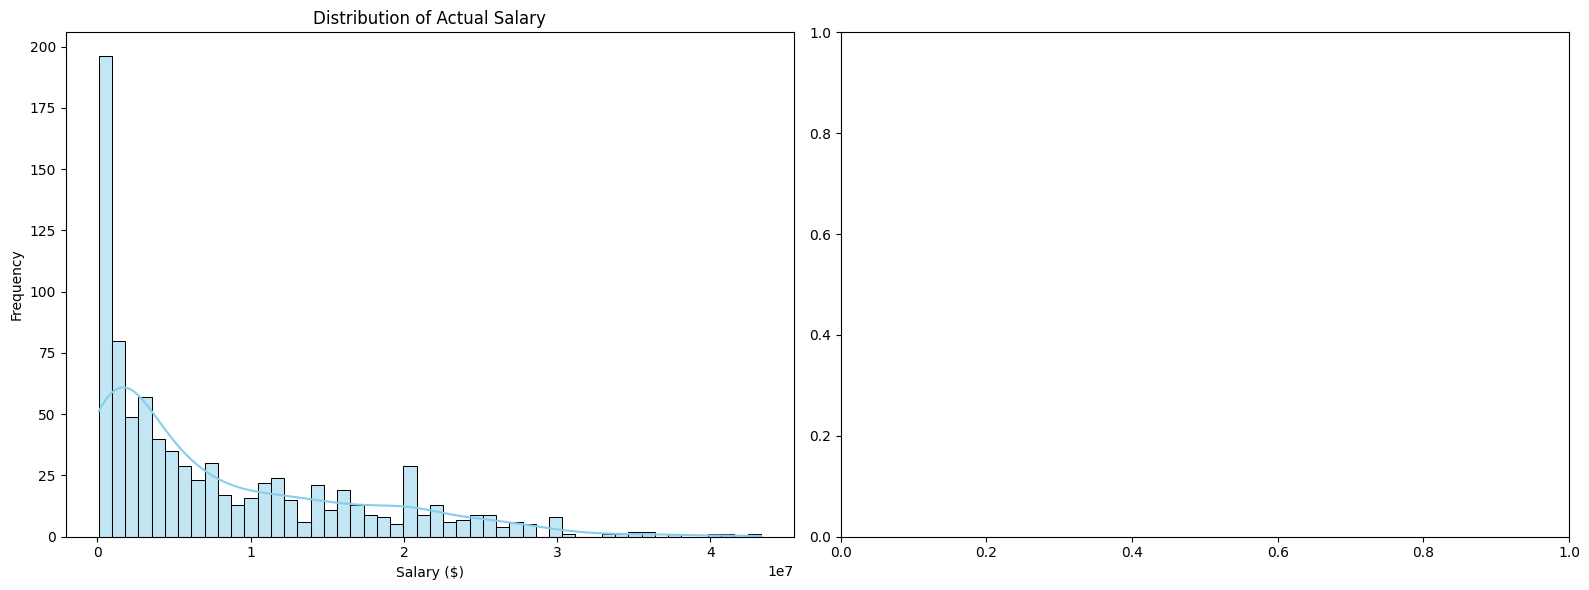

--- Salary Basic Statistics ---
count         854.000000
mean      8018495.531616
std       8494922.505321
min         82809.000000
25%       1026805.250000
50%       4500000.000000
75%      13000000.000000
max      43300000.000000
Name: target_salary, dtype: object


In [ ]:


# グラフの作成
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. 生の年俸分布（Actual Salary）
sns.histplot(df_model['target_salary'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Actual Salary')
ax[0].set_xlabel('Salary ($)')
ax[0].set_ylabel('Frequency')

# 2. 対数変換後の年俸分布（Log Salary）
# 1を加えるのは、もし0がある場合にエラーを防ぐため（log1p）
#df_model['log_salary'] = np.log1p(df_model['target_salary'])
#sns.histplot(df_model['log_salary'], bins=30, kde=True, ax=ax[1], color='salmon')
#ax[1].set_title('Distribution of Log-Transformed Salary')
#ax[1].set_xlabel('Log(Salary)')
#ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 基本統計量の確認
print("--- Salary Basic Statistics ---")
print(df_model['target_salary'].describe().apply(lambda x: format(x, 'f')))

In [ ]:
print(df_model[df_model['target_salary'] < 500000][['Name_Clean', 'target_salary', 'PA']])

                Name_Clean  target_salary   PA
13               Ben Gamel       464757.0  550
16        Brandon Phillips       169398.0  604
26            Chris Taylor       485218.0  568
34          Dansby Swanson       498719.0  551
116            Tim Beckham       304668.0  575
246             Tommy Pham       190030.0  570
277         Bryan Reynolds       486392.0  546
298          Franmil Reyes       184032.0  548
377  Vladimir Guerrero Jr.       468488.0  514
387           Adam Frazier       214690.0  639
430            Javier Báez       199355.0  547
443          Jose Iglesias        82809.0  511
470            Myles Straw       206310.0  638
473             Nick Solak       497858.0  511
489         Starling Marte       205489.0  526
501           Willy Adames       431400.0  555
521          Brandon Drury       316480.0  568
537           Elvis Andrus       184608.0  577
553          Jesús Aguilar       130764.0  507
679       Jurickson Profar        89033.0  521
698          

In [ ]:
# 最低年俸（約74万ドル）を基準に設定

min_salary_threshold = 700000

# フィルタリング実行
df_model_cleaned = df_model[df_model['target_salary'] >= min_salary_threshold].copy()

print(f"除去前のデータ件数: {len(df_model)}件")
print(f"除去後のデータ件数: {len(df_model_cleaned)}件")
print(f"除去された人数: {len(df_model) - len(df_model_cleaned)}人")

除去前のデータ件数: 854件
除去後のデータ件数: 695件
除去された人数: 159人


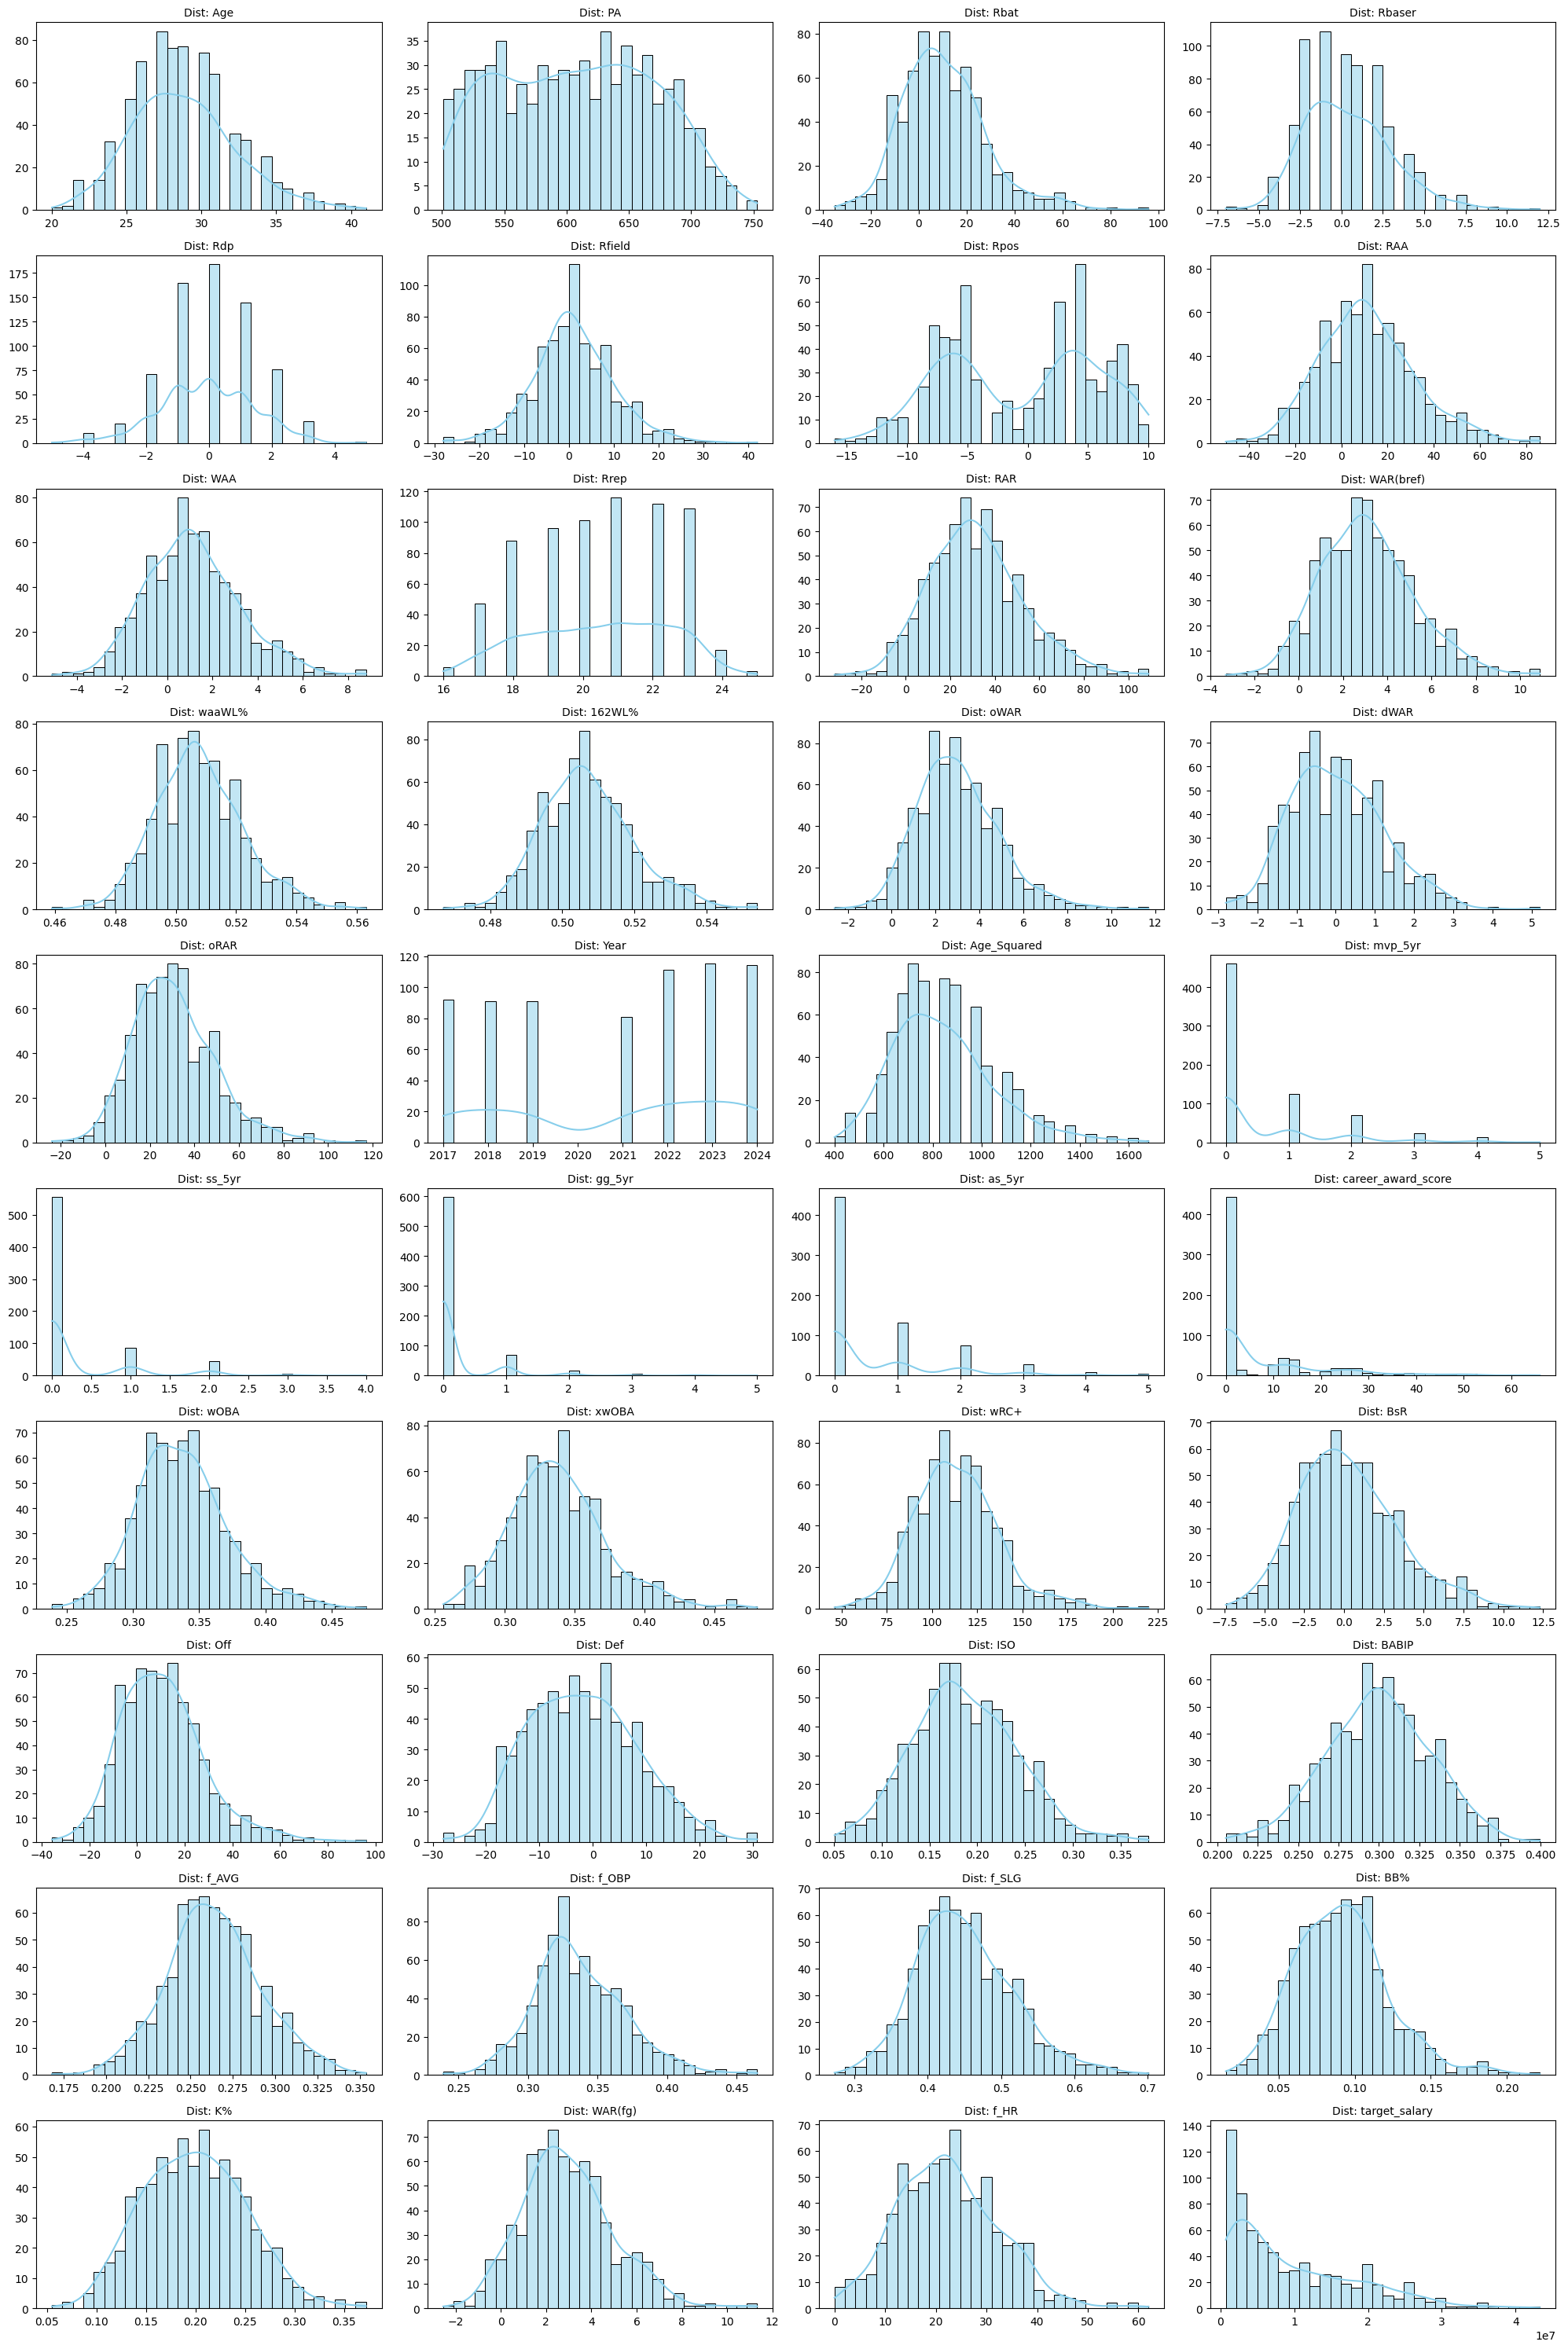

In [ ]:
# 数値データのみ抽出
data_num = df_model_cleaned[num_cols]

# 指標の数に合わせてグリッドを自動計算
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data_num[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Dist: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 余った空白グラフを消す
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# 1. 全数値指標の相関行列
full_corr = df_model_cleaned.select_dtypes(include=[np.number]).corr()

# 2. 相関が0.9以上のペアを抽出
high_corr_list = []
for i in range(len(full_corr.columns)):
    for j in range(i):
        coef = full_corr.iloc[i, j]
        if abs(coef) > 0.9:
            high_corr_list.append({
                'Feature 1': full_corr.columns[i],
                'Feature 2': full_corr.columns[j],
                'Correlation': coef
            })

# 結果を表示
df_high_corr = pd.DataFrame(high_corr_list)
print("--- 相関が0.9以上のペア（ ---")
print(df_high_corr.sort_values(by='Correlation', ascending=False))

--- 相関が0.9以上のペア（ ---
             Feature 1  Feature 2  Correlation
20                oRAR       oWAR     0.998706
6            WAR(bref)        RAR     0.997381
0                  WAA        RAA     0.996760
21         Age_Squared        Age     0.996535
5            WAR(bref)        WAA     0.996388
2                  RAR        RAA     0.995772
11              162WL%        RAA     0.995415
7               waaWL%        RAA     0.995023
3                  RAR        WAA     0.994680
12              162WL%        WAA     0.993080
8               waaWL%        WAA     0.992386
4            WAR(bref)        RAA     0.992203
15              162WL%     waaWL%     0.991657
13              162WL%        RAR     0.991085
14              162WL%  WAR(bref)     0.988199
9               waaWL%        RAR     0.987728
22  career_award_score    mvp_5yr     0.987719
10              waaWL%  WAR(bref)     0.984727
24                wRC+       Rbat     0.982217
26                 Off       Rbat     0

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 診断対象にする特徴量（前回の精鋭リスト + α）
# NaNがあるとエラーになるため、一度dropnaするか、平均値で埋める
vif_target_features = [
    'Age', 'PA', 'WAR(fg)', 'WAR(bref)', 'wRC+', 'xwOBA',
    'ISO', 'BB%', 'K%', 'f_AVG', 'f_HR', 'Def', 'BsR', 'Rpos','career_award_score'
]

X_vif = df_model_cleaned[vif_target_features].dropna()

# VIFの計算
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- VIFスコア ---")
print(vif_data.sort_values(by='VIF', ascending=False))


--- VIFスコア ---
               feature         VIF
4                 wRC+  986.318138
5                xwOBA  468.044838
9                f_AVG  445.806691
6                  ISO  247.341207
1                   PA  150.764527
10                f_HR  120.807062
2              WAR(fg)  116.209748
0                  Age   92.197944
7                  BB%   30.484053
8                   K%   24.659062
3            WAR(bref)   24.057736
11                 Def   10.233360
13                Rpos    2.806877
12                 BsR    2.520304
14  career_award_score    1.887024


In [ ]:
# 限界まで削ぎ落とした精鋭リスト
vif_final_features = [
    'Age',       # 年齢（必須）
    'Age_Squared',
    'PA',        # 出場機会（必須）
    'WAR(bref)', # 総合貢献度
    'wRC+',      # 打撃の質（これ1本に絞る）
    'BB%',       # 選球眼
    'K%',        # コンタクト能力
    'Def',       # 守備力
    'BsR',      # 走塁
    'career_award_score'

]

# 再度VIFを確認するためのコード
X_vif_final = df_model_cleaned[vif_final_features].dropna()
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_vif_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]
print(vif_data_final.sort_values(by='VIF', ascending=False))

              feature          VIF
0                 Age  1088.254416
1         Age_Squared   356.699291
4                wRC+   148.089561
2                  PA   137.450921
3           WAR(bref)    21.834210
6                  K%    17.847649
5                 BB%    14.854555
7                 Def     2.476956
9  career_award_score     1.744475
8                 BsR     1.423508


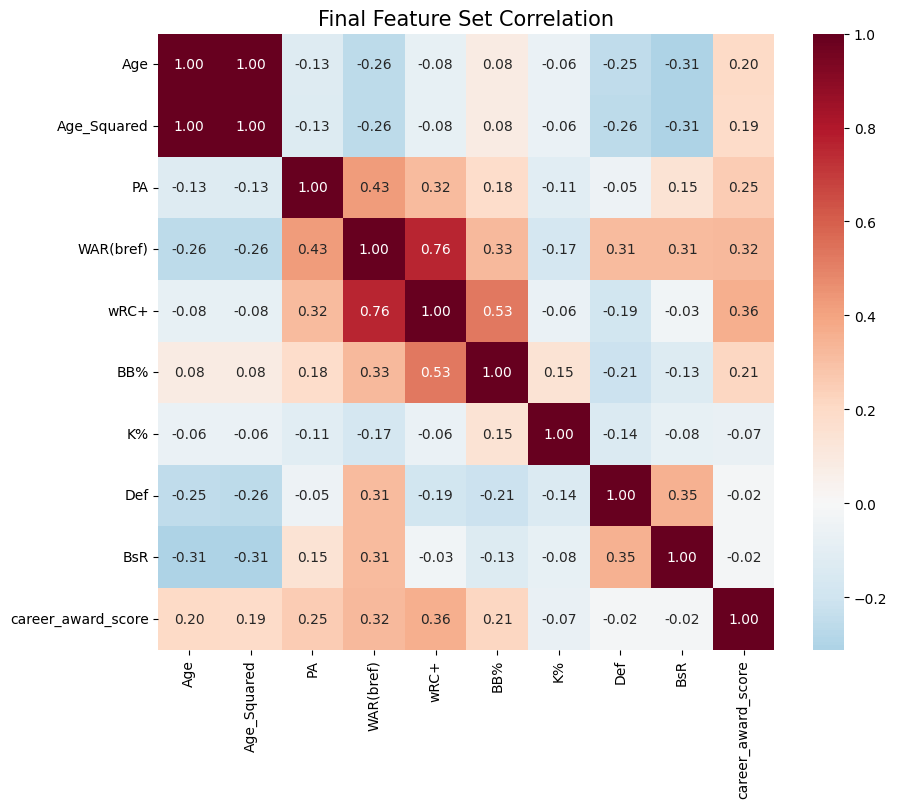

In [ ]:


plt.figure(figsize=(10, 8))
sns.heatmap(df_model_cleaned[vif_final_features].corr(),
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            square=True)

plt.title('Final Feature Set Correlation', fontsize=15)
plt.show()

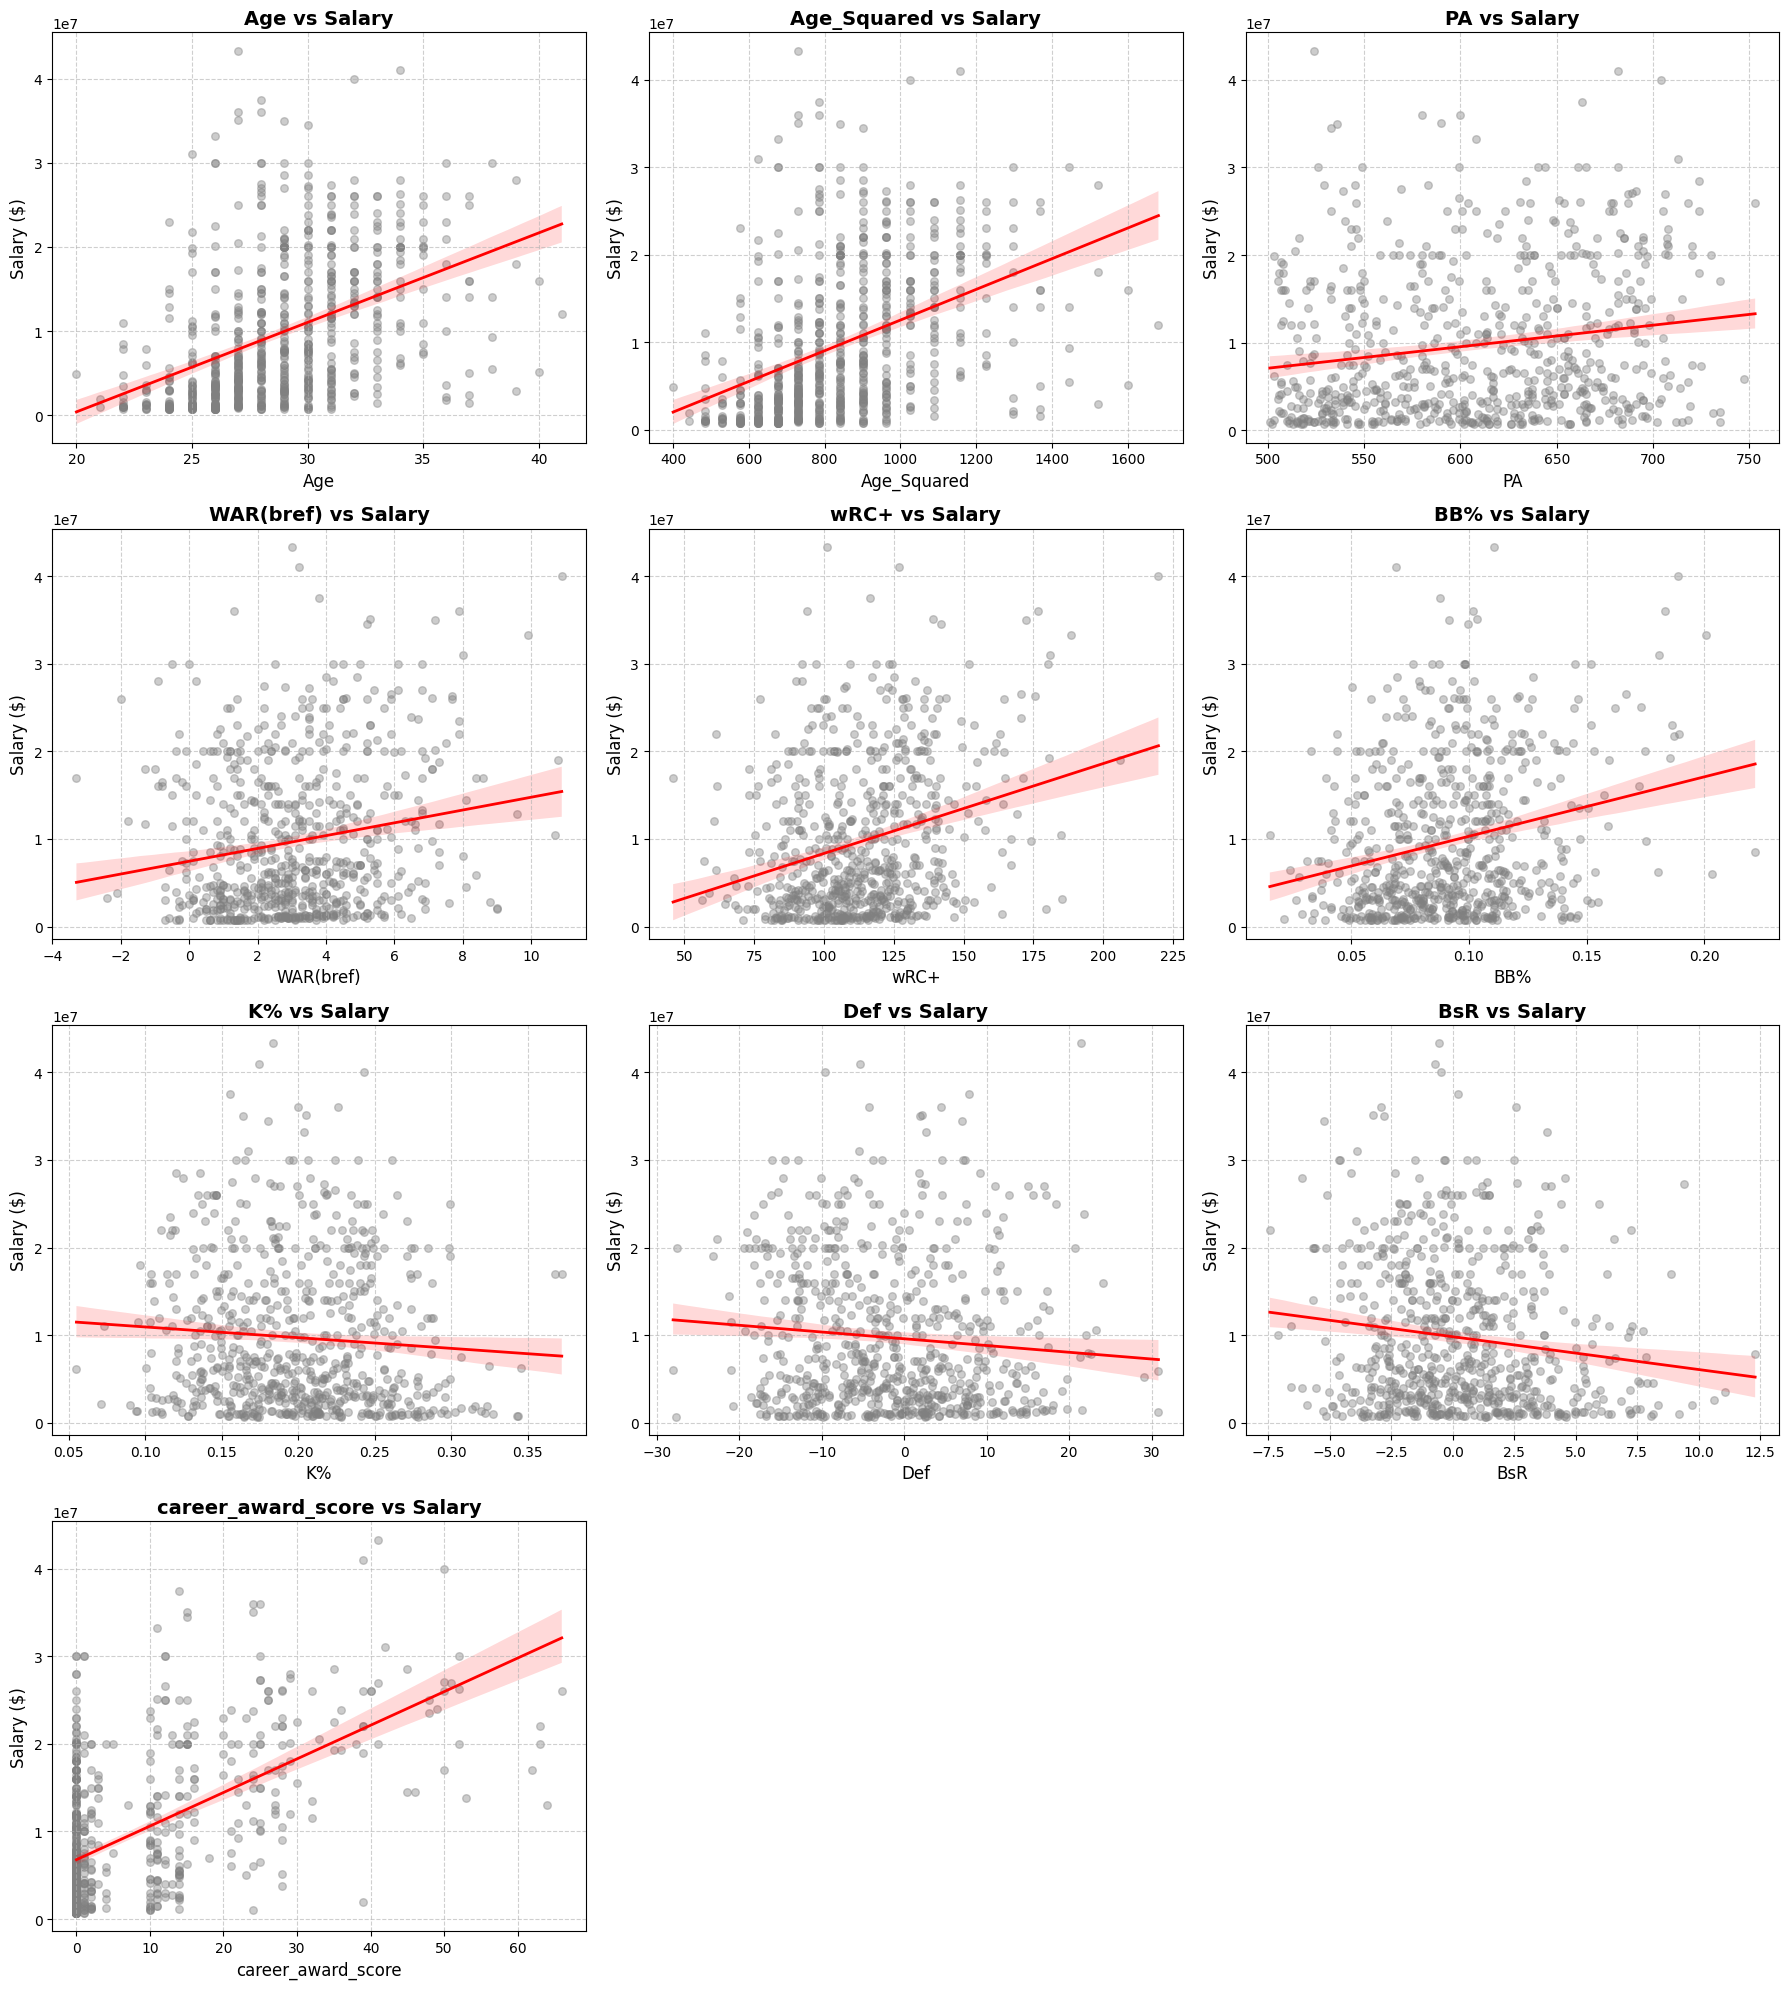

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns



# グリッドのサイズを計算
n_features = len(vif_final_features)
n_cols = 3 # 精鋭なので1行3つが見やすいです
n_rows = math.ceil(n_features / n_cols)

# プロットの作成
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(vif_final_features):
    # regplotで散布図と回帰直線を描画
    sns.regplot(data=df_model_cleaned, x=col, y='target_salary', ax=axes[i],
                scatter_kws={'alpha': 0.4, 's': 30, 'color': 'gray'},
                line_kws={'color': 'red', 'lw': 2})

    axes[i].set_title(f'{col} vs Salary', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Salary ($)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 余った空白のプロットを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

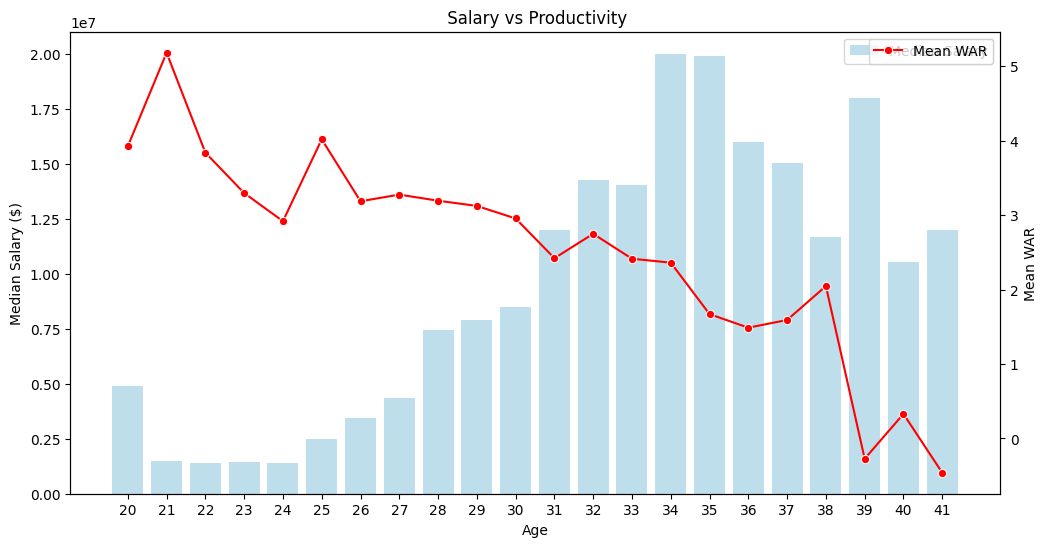

In [ ]:
# 年齢ごとの年俸中央値と平均WARを算出
age_stats = df_model_cleaned.groupby('Age').agg({
    'target_salary': 'median',
    'WAR(fg)': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 年俸の推移（棒グラフ）
sns.barplot(data=age_stats, x='Age', y='target_salary', ax=ax1, color='skyblue', alpha=0.6, label='Median Salary')
ax1.set_ylabel('Median Salary ($)')

# WARの推移（折れ線グラフ）
ax2 = ax1.twinx()
sns.lineplot(data=age_stats, x=age_stats.index, y='WAR(fg)', ax=ax2, color='red', marker='o', label='Mean WAR')
ax2.set_ylabel('Mean WAR')

plt.title(' Salary vs Productivity')
plt.show()

In [ ]:
# 28歳以上をベテランとするフラグの作成
df_model_cleaned['is_veteran'] = (df_model_cleaned['Age'] >= 28).astype(int)

In [ ]:
import re

def categorize_pos_bref(pos):
    pos = str(pos).upper()

    # 1. 捕手 (2)
    if '2' in pos: return 'Catcher'

    # 2. 内野手 (3:1B, 4:2B, 5:3B, 6:SS)
    if any(n in pos for n in ['3', '4', '5', '6']): return 'Infield'

    # 3. 外野手 (7:LF, 8:CF, 9:RF)
    if any(n in pos for n in ['7', '8', '9']): return 'Outfield'

    # 4. 指名打者 (D)
    if 'D' in pos: return 'DH'

    return 'Other'

# 適用
df_model_cleaned['Pos_Group'] = df_model_cleaned['Pos'].apply(categorize_pos_bref)

# 件数確認
print(df_model_cleaned['Pos_Group'].value_counts())

Pos_Group
Infield     436
Outfield    217
Catcher      35
DH            7
Name: count, dtype: int64


/tmp/ipykernel_58688/2521855518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', palette='Set2', showfliers=False)


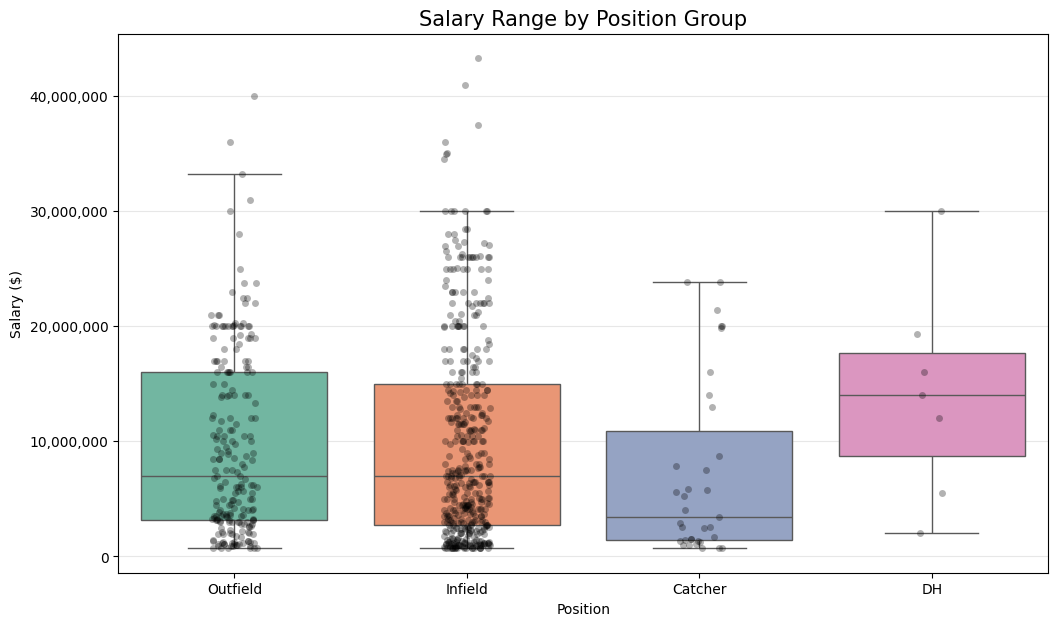

In [ ]:
plt.figure(figsize=(12, 7))

# 箱ひげ図に個々のデータを重ねる（スウォームプロット）
sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', palette='Set2', showfliers=False)
sns.stripplot(data=df_model_cleaned, x='Pos_Group', y='target_salary', color='black', alpha=0.3, jitter=True)

plt.title('Salary Range by Position Group', fontsize=15)
plt.ylabel('Salary ($)')
plt.xlabel('Position')
# y軸を読みやすく（例：10Mなど）
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_58688/784984157.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Team', y='target_salary', order=team_order, palette='vlag')


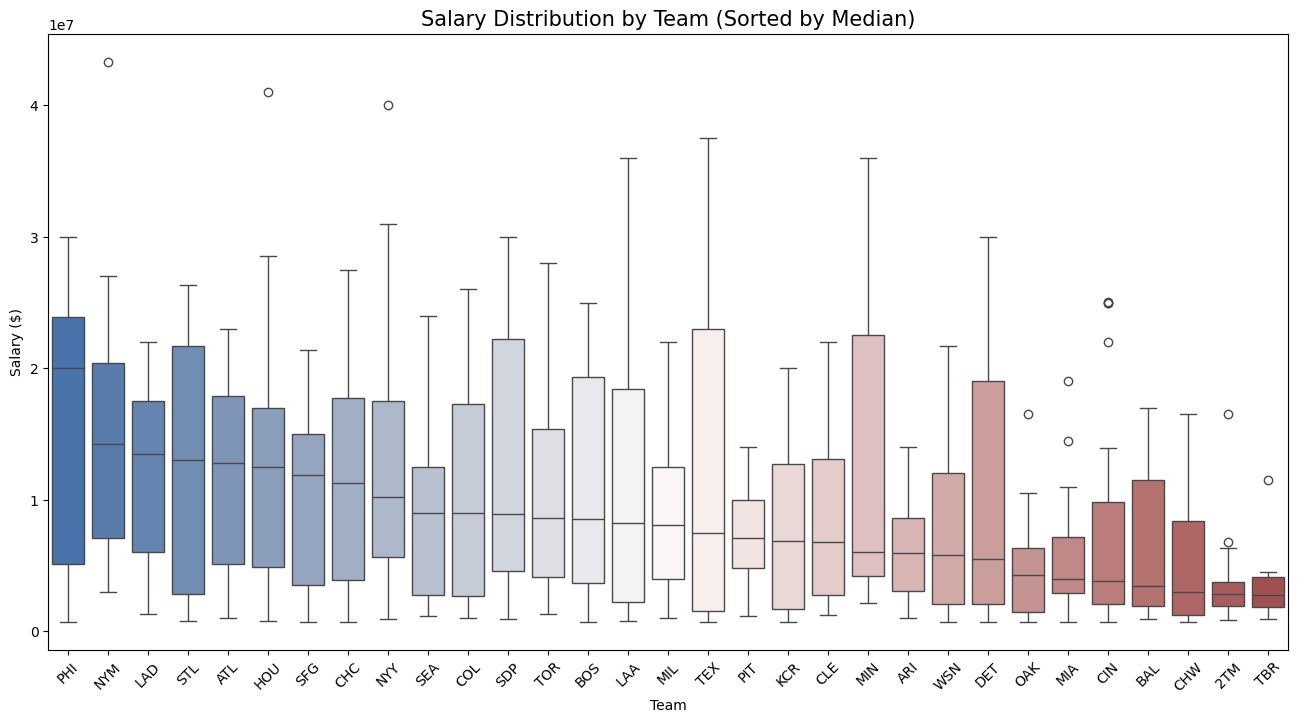

In [ ]:
plt.figure(figsize=(16, 8))

# チームごとの中央値でソート
team_order = df_model_cleaned.groupby('Team')['target_salary'].median().sort_values(ascending=False).index

sns.boxplot(data=df_model_cleaned, x='Team', y='target_salary', order=team_order, palette='vlag')
plt.xticks(rotation=45)
plt.title('Salary Distribution by Team (Sorted by Median)', fontsize=15)
plt.ylabel('Salary ($)')
plt.show()

In [ ]:



final_numeric_features = [
    'Age','Age_Squared', 'is_veteran', 'PA', 'WAR(bref)', 'wRC+', 'ISO', 'BB%', 'K%', 'Def', 'BsR', 'career_award_score'
]

# カテゴリ変数（チームとポジション）
final_category_features = ['Team', 'Pos_Group']



In [ ]:
from sklearn.model_selection import train_test_split

# 3. ダミー変数化（drop_first=False で全カテゴリを保持）
#X = df_model_cleaned[final_numeric_features ]
#df_model = df_model_cleaned[df_model_cleaned['target_salary'] <= 20_000_000].copy()
X = df_model_cleaned[final_numeric_features + final_category_features]
X_final = pd.get_dummies(X, columns=['Team', 'Pos_Group'], drop_first=False)

y = np.log1p(df_model_cleaned['target_salary'])

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"--- 学習準備完了 ---")
print(f"学習サンプル数: {len(X_train)} 件")
print(f"テストサンプル数: {len(X_test)} 件")
print(f"特徴量の総数: {X_final.shape[1]} (チーム・ポジションのダミー変数を含む)")

--- 学習準備完了 ---
学習サンプル数: 556 件
テストサンプル数: 139 件
特徴量の総数: 47 (チーム・ポジションのダミー変数を含む)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. モデル定義
model_rf = RandomForestRegressor(
    n_estimators=100,      # 木の数
    random_state=42,       # 再現性のためのシード
    n_jobs=-1              # 全CPUコアを使用して高速化
)

# 2. 学習
print("Training Random Forest model...")
model_rf.fit(X_train, y_train)

# 3. 予測と評価
y_pred_rf_log = model_rf.predict(X_test)

# --- 評価用 ---
# 対数変換を元に戻して(expm1)ドル単位で誤差を計算
mae_rf_vet = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf_log))

print(f"Random Forest  MAE: ${mae_rf_vet:,.0f}")

Training Random Forest model...
Random Forest  MAE: $4,637,117


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. モデル定義
model_lgb = LGBMRegressor(
    n_estimators=100,      # 木の数
    learning_rate=0.05,    # 学習率
    random_state=42,       # 再現性のためのシード
    n_jobs=-1              # 全CPUコアを使用
)


model_lgb.fit(X_train, y_train)

# 3. 予測と評価
y_pred_lgb_log = model_lgb.predict(X_test)

# --- 評価用 ---
# 対数変換を元に戻して(expm1)ドル単位で誤差を計算
mae_lgb_vet = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(y_pred_lgb_log)
)

print(f"LightGBM MAE: ${mae_lgb_vet:,.0f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1429
[LightGBM] [Info] Number of data points in the train set: 556, number of used features: 26
[LightGBM] [Info] Start training from score 15.577346
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
from xgboost import XGBRegressor
import xgboost as xgb
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb_log = model_xgb.predict(X_test)
y_pred = np.expm1(y_pred_xgb_log) # 対数から戻す


mae = mean_absolute_error(np.expm1(y_test), y_pred)
print(f"Mean Absolute Error: ${mae:,.0f}")

Mean Absolute Error: $4,694,901


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. 各モデルの予測値を実際のドル単位（反対数）に変換
y_actual = np.expm1(y_test)
results_lgb = np.expm1(y_pred_lgb_log)
results_xgb = np.expm1(y_pred_xgb_log)
results_rf = np.expm1(y_pred_rf_log)

# 2. まとめのデータフレーム作成
evaluation_summary = [
    {
        "Model": "LightGBM",
        "MAE (USD)": mean_absolute_error(y_actual, results_lgb),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_lgb) * 100,
        "R2 Score": r2_score(y_test, y_pred_lgb_log)
    },
    {
        "Model": "XGBoost",
        "MAE (USD)": mean_absolute_error(y_actual, results_xgb),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_xgb) * 100,
        "R2 Score": r2_score(y_test, y_pred_xgb_log)
    },
    {
        "Model": "Random Forest",
        "MAE (USD)": mean_absolute_error(y_actual, results_rf),
        "MAPE (%)": mean_absolute_percentage_error(y_actual, results_rf) * 100,
        "R2 Score": r2_score(y_test, y_pred_rf_log)
    }
]

summary_df = pd.DataFrame(evaluation_summary)

# 表示用にフォーマットを整える（計算用の数値は保持しつつ、見た目を変える）
display_df = summary_df.copy()
display_df["MAE (USD)"] = display_df["MAE (USD)"].apply(lambda x: f"${x:,.0f}")
display_df["MAPE (%)"] = display_df["MAPE (%)"].apply(lambda x: f"{x:.2f}%")
display_df["R2 Score"] = display_df["R2 Score"].apply(lambda x: f"{x:.4f}")

# 3. 表示
print("="*60)
print("      MLB Salary Prediction: Final Evaluation")
print("="*60)
print(display_df.to_string(index=False))
print("-" * 60)

# 4. 最も良いモデルを自動判定（MAPEが最小のもの）
# MAEでも良いですが、相対的な精度の指標としてMAPEを使用します
best_model_idx = summary_df['MAPE (%)'].idxmin()
best_model_name = summary_df.loc[best_model_idx, 'Model']



      MLB Salary Prediction: Final Evaluation
        Model  MAE (USD) MAPE (%) R2 Score
     LightGBM $4,628,077   58.04%   0.5399
      XGBoost $4,694,901   62.13%   0.4722
Random Forest $4,637,117   57.05%   0.5819
------------------------------------------------------------


/tmp/ipykernel_58688/1837320197.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


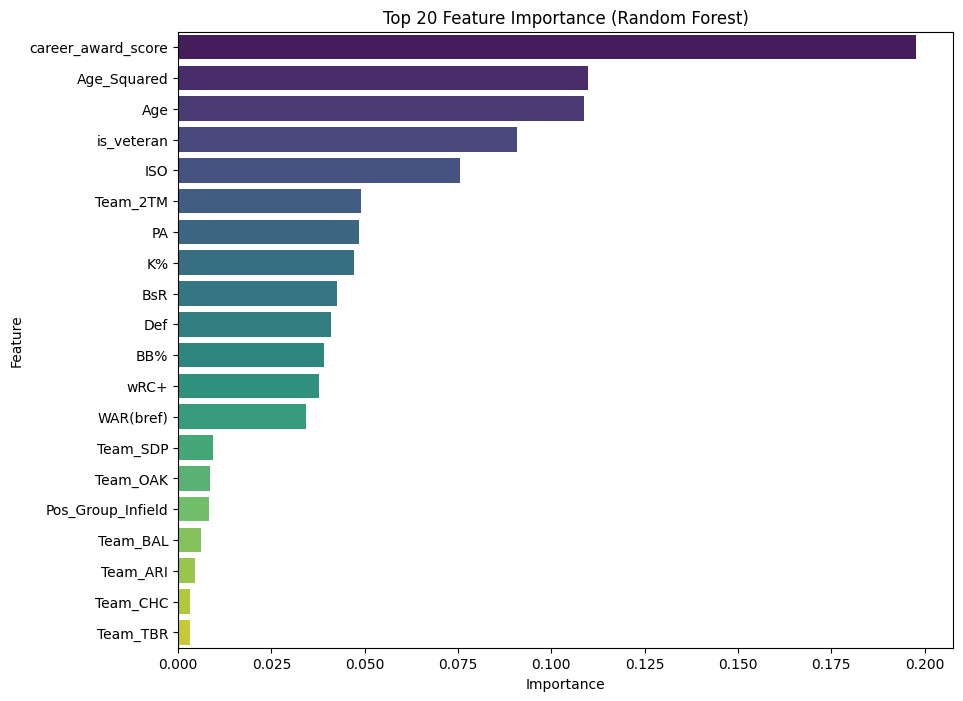

In [ ]:
# Random Forest の重要度を可視化
import pandas as pd
import matplotlib.pyplot as plt

# model は学習済みの RandomForestRegressor
importances = model_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 上位20個を表示
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.show()

/tmp/ipykernel_58688/3790494728.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')


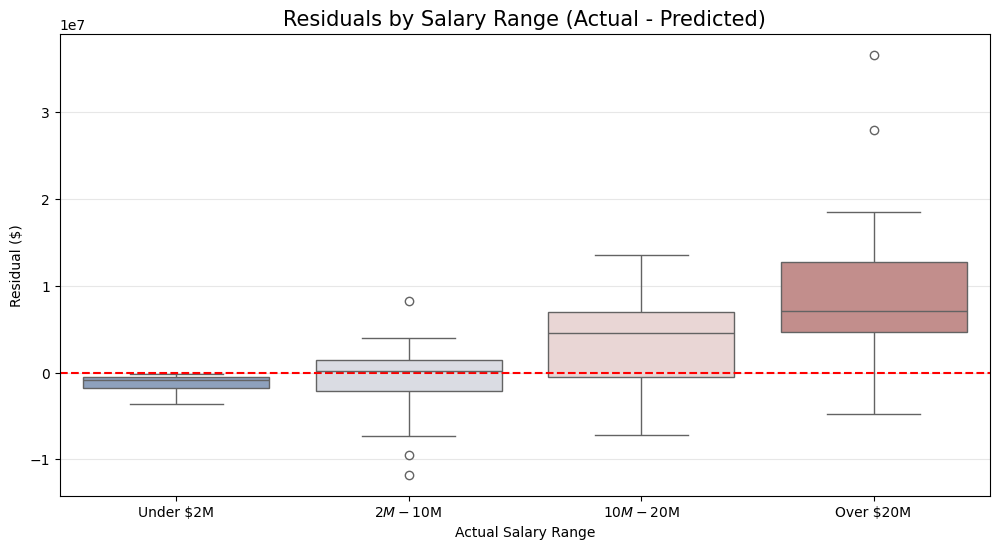

--- 年俸帯別・残差統計 ---
                      mean           std  count
Salary_Range                                   
Under $2M    -1.178570e+06  9.087249e+05     20
$2M-$10M     -4.873340e+05  3.564385e+06     58
$10M-$20M     3.514612e+06  5.753664e+06     34
Over $20M     9.041445e+06  8.823082e+06     27


/tmp/ipykernel_58688/3790494728.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 予測結果の集約（Random Forestの結果を使用する例）
# 注: すでに y_test と y_pred_rf_log がある前提です
results_df = pd.DataFrame({
    'Actual': np.expm1(y_test),
    'Predicted': np.expm1(y_pred_rf_log)
})

# 残差（誤差）を計算
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

# 2. 年俸帯別のグループ分け（4分位で分割、またはキリの良い数字で分割）
# ここでは分かりやすく金額でラベル付けします
bins = [0, 2000000, 10000000, 20000000, np.inf]
labels = ['Under $2M', '$2M-$10M', '$10M-$20M', 'Over $20M']
results_df['Salary_Range'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

# 3. 可視化：年俸帯別の残差分布
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')
plt.axhline(y=0, color='red', linestyle='--') # 誤差ゼロのライン

plt.title('Residuals by Salary Range (Actual - Predicted)', fontsize=15)
plt.ylabel('Residual ($)')
plt.xlabel('Actual Salary Range')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. 数値での確認
residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])
print("--- 年俸帯別・残差統計 ---")
print(residual_stats)

In [ ]:

results_df['Absolute_Error'] = results_df['Residual'].abs()
# 1. 予測結果と元のデータ（選手名や年齢など）をインデックスで結合
comparison_df = results_df.join(df_model_cleaned[['Name_Clean', 'Age', 'Team']])


# 2. 絶対誤差でソートしてトップ10を抽出
top_errors_named = comparison_df.sort_values('Absolute_Error', ascending=False).head(10)

# 3. 表示（見やすくするために列を整理）
print("--- 予測誤差が大きい選手トップ10 ---")
print(top_errors_named[['Name_Clean', 'Age', 'Team', 'Actual', 'Predicted', 'Residual']])

--- 予測誤差が大きい選手トップ10 ---
           Name_Clean  Age Team      Actual     Predicted      Residual
418  Francisco Lindor   27  NYM  43300000.0  6.661906e+06  3.663809e+07
525     Carlos Correa   27  MIN  35100000.0  7.182688e+06  2.791731e+07
351        Mike Trout   27  LAA  36000000.0  1.747059e+07  1.852941e+07
648      Corey Seager   29  TEX  35000000.0  1.906633e+07  1.593367e+07
697     Marcus Semien   32  TEX  26000000.0  1.234845e+07  1.365155e+07
97     Miguel Cabrera   34  DET  28000000.0  1.438066e+07  1.361934e+07
207       Kyle Seager   30  SEA  18500000.0  4.945023e+06  1.355498e+07
634     Brandon Nimmo   30  NYM  20250000.0  6.706984e+06  1.354302e+07
154       Chris Davis   32  BAL  17000000.0  4.575651e+06  1.242435e+07
436        Joey Votto   37  CIN  25000000.0  1.307755e+07  1.192245e+07


/tmp/ipykernel_58688/2649161.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot")


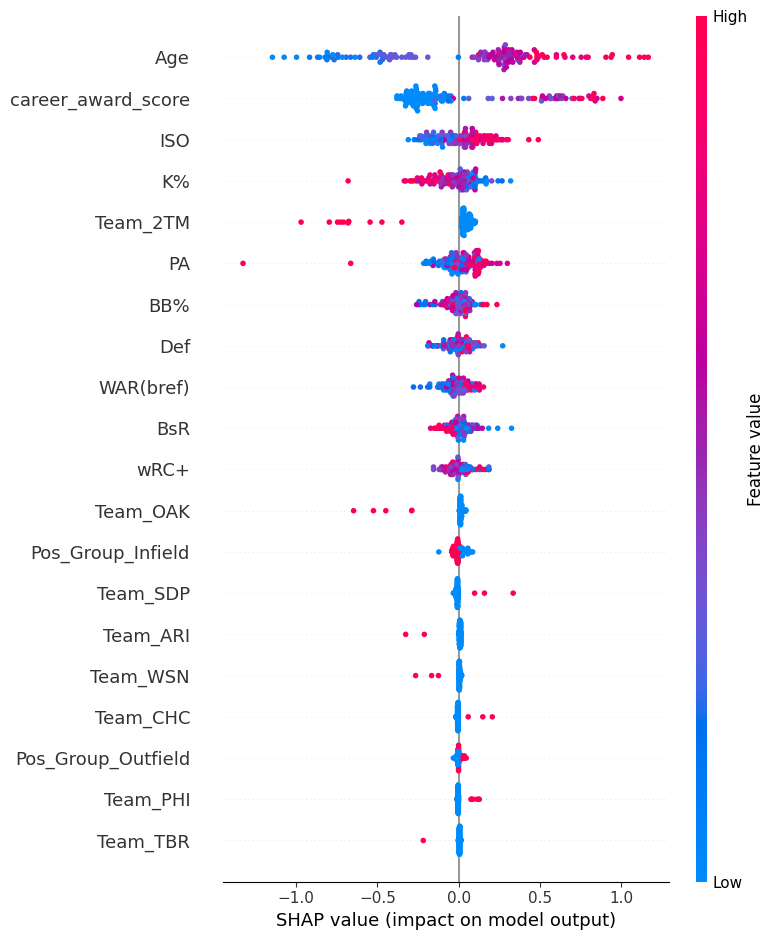

In [ ]:
import shap

# 1. Explainerの初期化 (XGBoostモデルを使用する例)
# model_xgb は学習済みのモデル、X_test はテスト用の特徴量行列
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot (全体の寄与度)
# どの特徴量が、予測値をプラス方向（高年俸）またはマイナス方向（低年俸）に押し上げたか
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

--- 予測誤差が大きい選手トップ5のSHAP分析 ---

No.1: Francisco Lindor
Actual: $43,300,000 / Predicted: $6,661,906


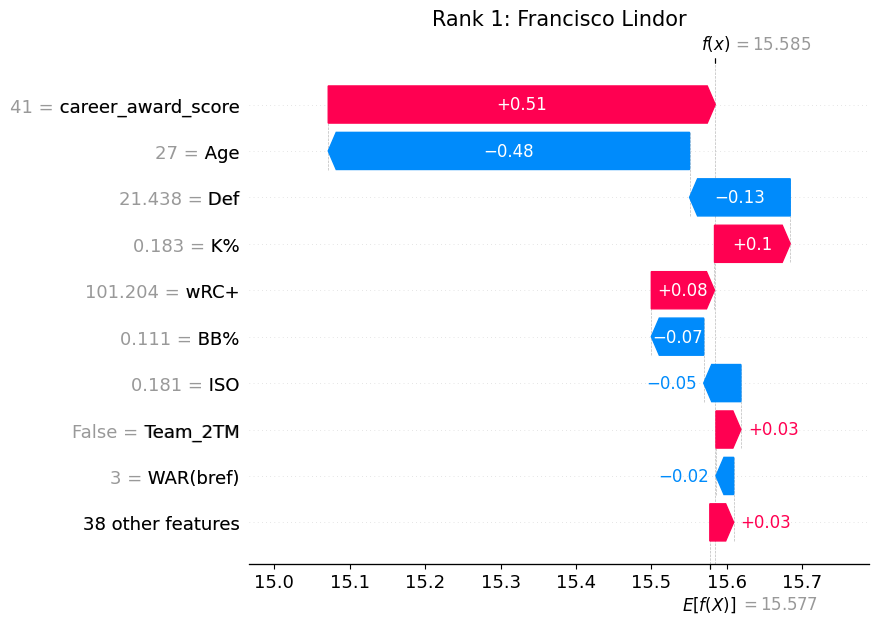


No.2: Carlos Correa
Actual: $35,100,000 / Predicted: $7,182,688


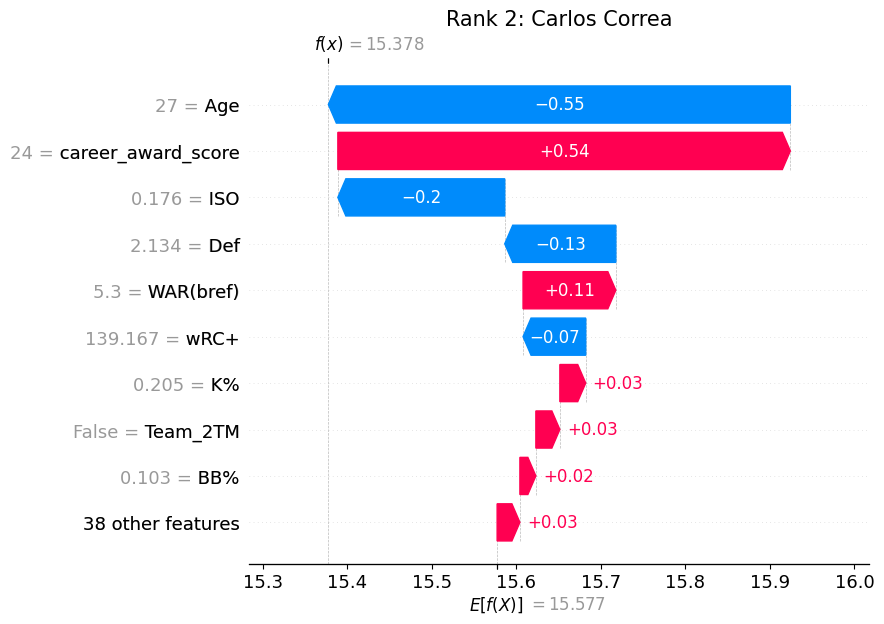


No.3: Mike Trout
Actual: $36,000,000 / Predicted: $17,470,587


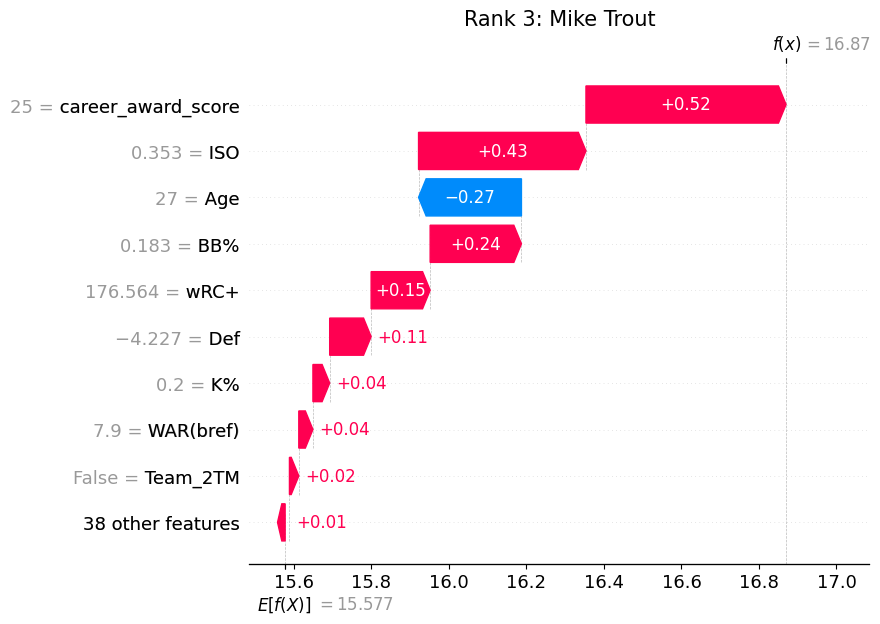


No.4: Corey Seager
Actual: $35,000,000 / Predicted: $19,066,329


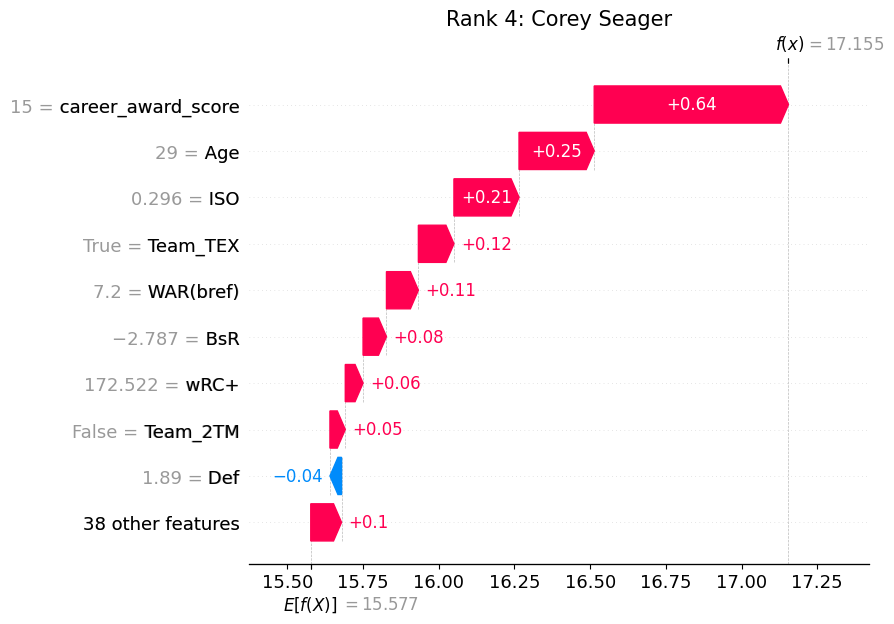


No.5: Marcus Semien
Actual: $26,000,000 / Predicted: $12,348,447


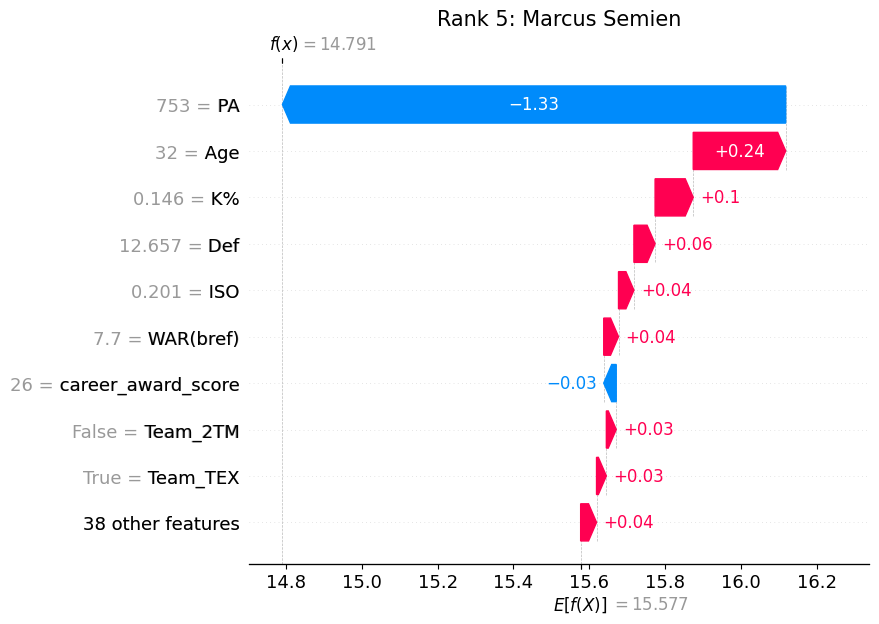


No.6: Miguel Cabrera
Actual: $28,000,000 / Predicted: $14,380,665


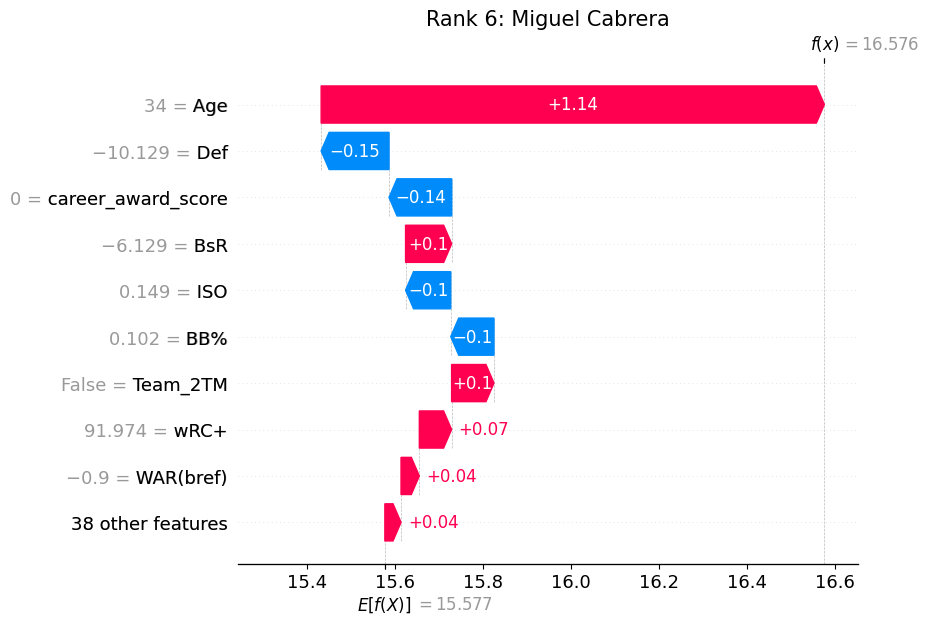


No.7: Kyle Seager
Actual: $18,500,000 / Predicted: $4,945,023


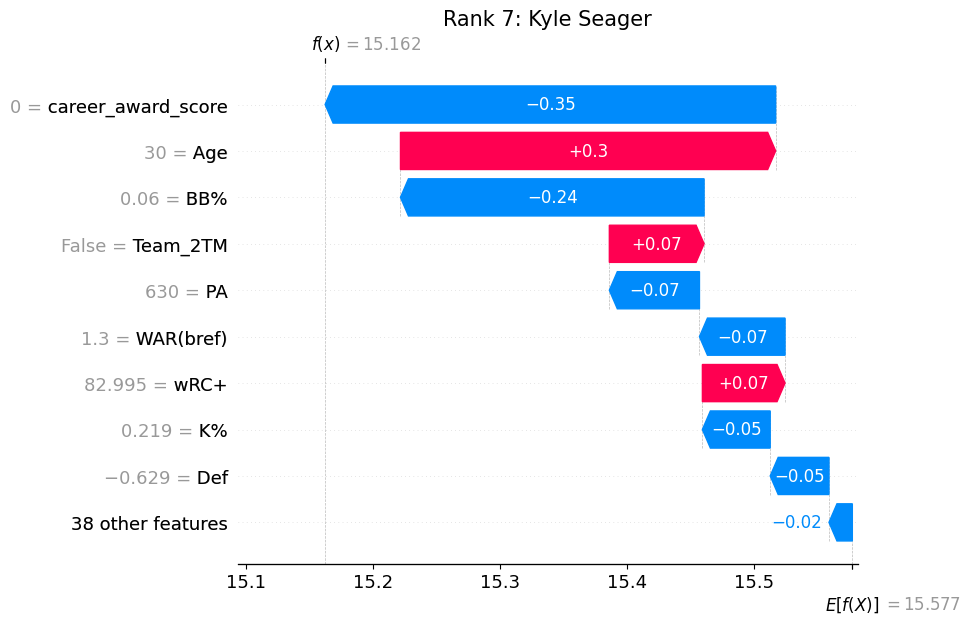


No.8: Brandon Nimmo
Actual: $20,250,000 / Predicted: $6,706,984


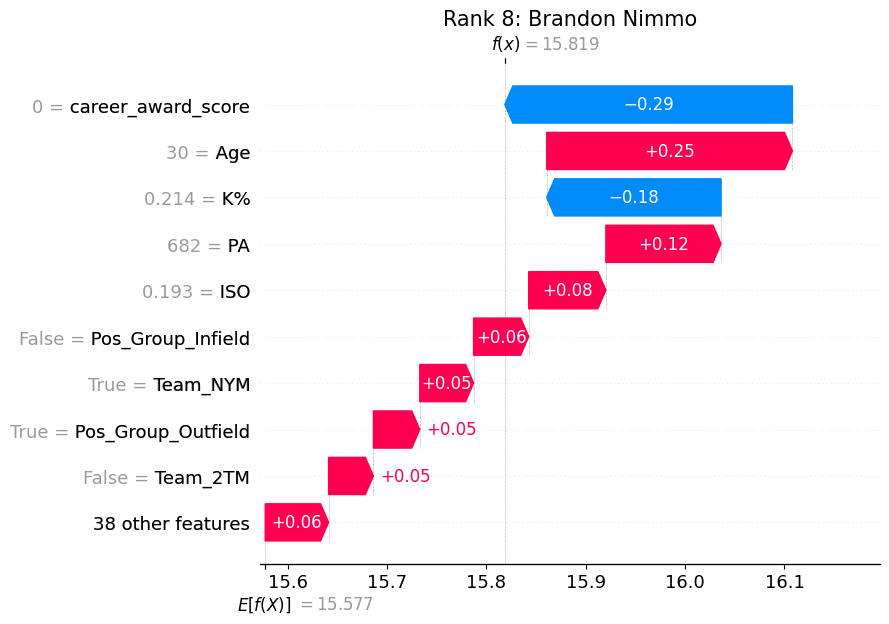


No.9: Chris Davis
Actual: $17,000,000 / Predicted: $4,575,651


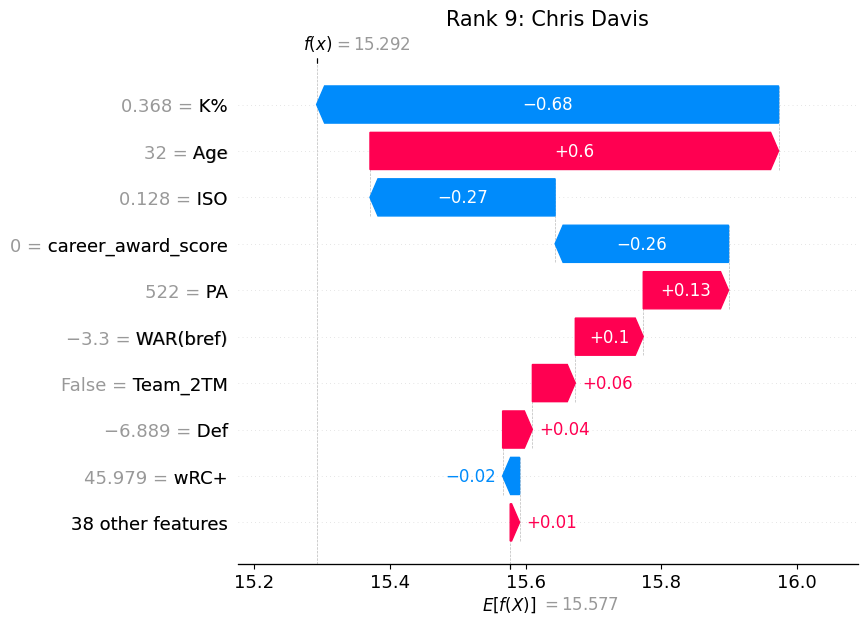


No.10: Joey Votto
Actual: $25,000,000 / Predicted: $13,077,551


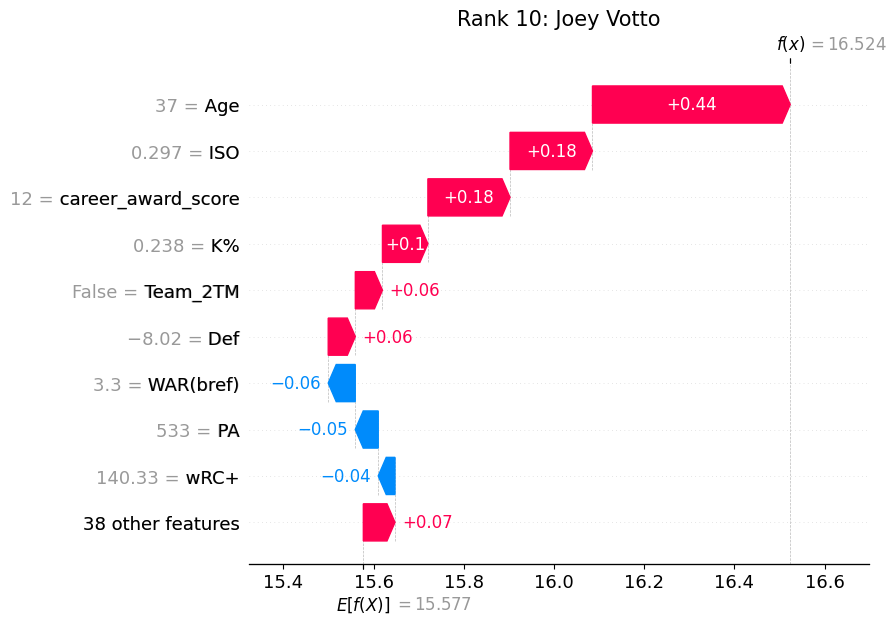

In [ ]:
import matplotlib.pyplot as plt

# 1. SHAP値を計算（計算済みの場合はスキップしてください）
shap_exp = explainer(X_test)

# 2. 誤差上位5人をループで回す
print("--- 予測誤差が大きい選手トップ5のSHAP分析 ---")

for i in range(10):
    # 誤差ランキングから元のインデックスを取得
    original_idx = top_errors_named.index[i]

    # X_testの中での「何番目の位置か」を特定
    row_pos = X_test.index.get_loc(original_idx)

    # 表示用の情報を取得
    player_name = top_errors_named.loc[original_idx, 'Name_Clean']
    actual_val = top_errors_named.loc[original_idx, 'Actual']
    pred_val = top_errors_named.loc[original_idx, 'Predicted']

    # ログ出力
    print(f"\nNo.{i+1}: {player_name}")
    print(f"Actual: ${actual_val:,.0f} / Predicted: ${pred_val:,.0f}")

    # グラフの描画
    # waterfall内で直接タイトルを付けるのが難しいため、plt.titleを使用します
    shap.plots.waterfall(shap_exp[row_pos], show=False)
    plt.title(f"Rank {i+1}: {player_name}", fontsize=15)
    plt.show()

In [ ]:
# DuckDBの内容をDriveに同期
con.close()
shutil.copy(LOCAL_DB_PATH, os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'))
print("Database synced to Google Drive.")

Database synced to Google Drive.
